In [8]:
#import neccessary libs for project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#loading the Ai ranking Data set
df=pd.read_csv("ai_model_arena_rankings.csv")
df.head()

,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset
0,vicuna-13b,LMSYS,Llama 2 Community,1094.0,NaN,NaN,NaN,NaN,1.0,overall,2023-05-08,text
1,koala-13b,UC Berkeley,Non-commercial,1015.0,NaN,NaN,NaN,NaN,2.0,overall,2023-05-08,text
2,RWKV-4-Raven-14B,RWKV,Apache 2.0,979.0,NaN,NaN,NaN,NaN,3.0,overall,2023-05-08,text
3,oasst-pythia-12b,OpenAssistant,Apache 2.0,941.0,NaN,NaN,NaN,NaN,4.0,overall,2023-05-08,text
4,alpaca-13b,Stanford,Non-commercial,935.0,NaN,NaN,NaN,NaN,5.0,overall,2023-05-08,text


In [10]:
df.shape

(97377, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97377 entries, 0 to 97376
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   model_name                97377 non-null  object 
 1   organization              93900 non-null  object 
 2   license                   97246 non-null  object 
 3   rating                    97377 non-null  float64
 4   rating_lower              97070 non-null  float64
 5   rating_upper              97070 non-null  float64
 6   variance                  97070 non-null  float64
 7   vote_count                97070 non-null  float64
 8   rank                      97377 non-null  float64
 9   category                  97377 non-null  object 
 10  leaderboard_publish_date  97377 non-null  object 
 11  subset                    97377 non-null  object 
dtypes: float64(6), object(6)
memory usage: 8.9+ MB


In [12]:
df.describe()

,rating,rating_lower,rating_upper,variance,vote_count,rank
count,97377.000000,97070.000000,97070.000000,97070.000000,97070.000000,97377.000000
mean,1232.582439,1226.333891,1240.476336,16.858066,23586.333728,119.164197
std,145.454932,146.240327,143.613960,20.661015,27389.381794,89.941677
min,789.000000,782.043296,800.000000,0.000000,54.000000,1.000000
25%,1125.959993,1119.161926,1135.238584,4.967224,5243.000000,43.000000
50%,1240.190789,1234.672228,1247.290220,10.444272,12857.000000,99.000000
75%,1348.771914,1343.719372,1356.460212,22.175828,32191.000000,180.000000
max,1664.985725,1644.632424,1685.339027,777.424034,202735.000000,374.000000


In [13]:
df.isnull().sum()

model_name                     0
organization                3477
license                      131
rating                         0
rating_lower                 307
rating_upper                 307
variance                     307
vote_count                   307
rank                           0
category                       0
leaderboard_publish_date       0
subset                         0
dtype: int64

In [14]:
df["leaderboard_publish_date"]= pd.to_datetime(df["leaderboard_publish_date"])
df["leaderboard_publish_date"].min(), df["leaderboard_publish_date"].max()

(Timestamp('2023-05-08 00:00:00'), Timestamp('2026-07-10 00:00:00'))

In [15]:
df["organization"]= df["organization"].fillna("Unkown")
df["license"]= df["license"].fillna("Unkown")

In [16]:
df.duplicated().sum()
df=df.drop_duplicates()

In [17]:
print(df["category"].unique())

['overall']


In [18]:
print(df["subset"].unique())

['text' 'text_style_control' 'vision' 'webdev' 'search']


In [19]:
#filter to the latest "overall/text" leaderboards
text_df=df[(df["subset"]=="text") & (df["category"]=="overall")].copy()
latest_text_date = text_df["leaderboard_publish_date"].max()
print("Latest text snapshot:", latest_text_date)

Latest text snapshot: 2026-07-10 00:00:00


In [20]:
model_df=text_df[text_df["leaderboard_publish_date"]== latest_text_date].copy()
print("Shape:", model_df.shape)
model_df.head()

Shape: (374, 12)


,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset
44749,claude-opus-4-6-thinking,anthropic,Proprietary,1501.176934,1497.393835,1504.960034,3.725628,58968.0,1.0,overall,2026-07-10,text
44750,claude-opus-4-6,anthropic,Proprietary,1497.505921,1493.815327,1501.196516,3.545655,62650.0,2.0,overall,2026-07-10,text
44751,claude-fable-5,anthropic,Proprietary,1495.077294,1485.712372,1504.442215,22.830324,4299.0,3.0,overall,2026-07-10,text
44752,claude-opus-4-7-thinking,anthropic,Proprietary,1490.153829,1485.832455,1494.475203,4.861244,46183.0,4.0,overall,2026-07-10,text
44753,claude-opus-4-7,anthropic,Proprietary,1482.446228,1478.133139,1486.759317,4.842623,47222.0,5.0,overall,2026-07-10,text


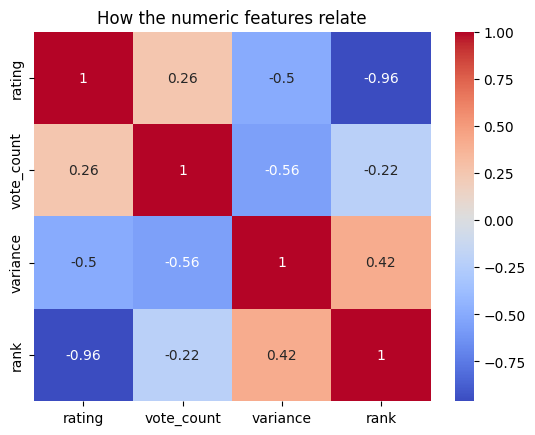

In [21]:
sns.heatmap(model_df[["rating","vote_count", "variance","rank"]].corr(),
           annot=True, cmap="coolwarm")
plt.title("How the numeric features relate")
plt.show()

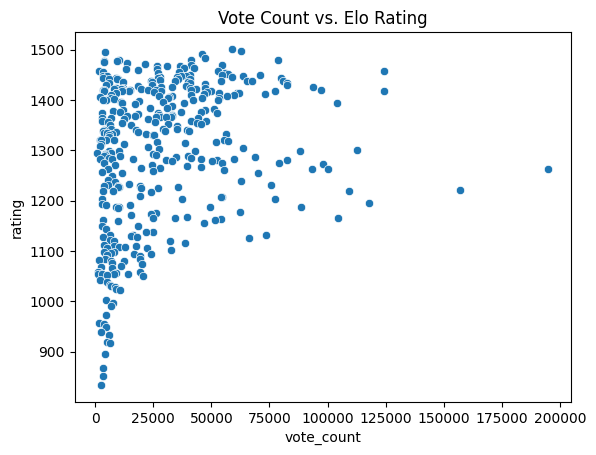

In [22]:
sns.scatterplot(data=model_df, x="vote_count", y="rating")
plt.title("Vote Count vs. Elo Rating")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# build and train model with sklearn
features=["vote_count", "variance"]
target= "rating"
data= model_df.dropna(subset=features +[target])
X=data[features]
Y=data[target]
print("Training on", X.shape[0], "models with", X.shape[1], "features")

Training on 374 models with 2 features


In [25]:
# Splitting training and test sets

X_train, X_test, Y_train, Y_test= train_test_split(
    X,Y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])

Train: 299 Test: 75


In [26]:
# Baseline model with linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
lr=LinearRegression()
lr.fit(X_train, Y_train)
pred=lr.predict(X_test)

print("R^2", round(r2_score(Y_test, pred)), 1)
print("RMSE:", round(np.sqrt(mean_squared_error(Y_test, pred)),1))

R^2 0 1
RMSE: 125.6


In [27]:
# --- all imports ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# --- 6a: features and target ---
features = ["vote_count", "variance"]
target   = "rating"

data = model_df.dropna(subset=features + [target])
X = data[features]
y = data[target]

# --- 6b: train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 6c: train and evaluate ---
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("Trained on", X_train.shape[0], "models")
print("R2  :", round(r2, 3))
print("RMSE:", round(rmse, 1))

Trained on 299 models
R2  : 0.294
RMSE: 125.6


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

num_features= ["vote_count", "variance"]
cat_features= ["organization","license"]
target="rating"
data=model_df.dropna(subset=num_features+ [target]).copy()

X=pd.get_dummies(data[num_features + cat_features], columns=cat_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

rf=RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred= rf.predict(X_test)

print("Features used:", X.shape[1])
print("R^2:", round(r2_score(y_test, pred),3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 1))

Features used: 66
R^2: 0.707
RMSE: 80.8


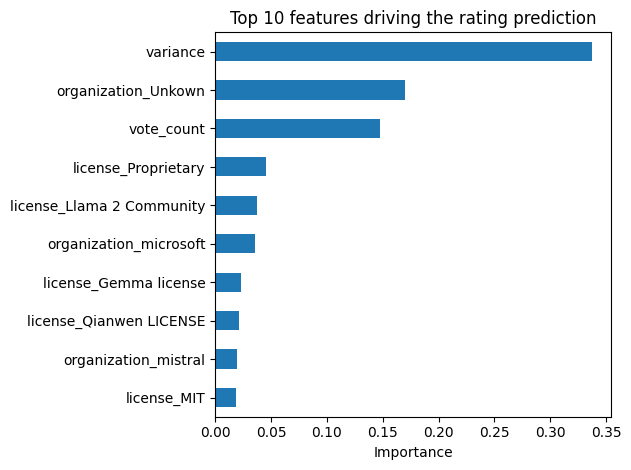

variance                     0.337713
organization_Unkown          0.169878
vote_count                   0.147984
license_Proprietary          0.045443
license_Llama 2 Community    0.037400
organization_microsoft       0.035453
license_Gemma license        0.022811
license_Qianwen LICENSE      0.021019
organization_mistral         0.019806
license_MIT                  0.018666
dtype: float64


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

top10.sort_values().plot(kind="barh")
plt.title("Top 10 features driving the rating prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(top10)

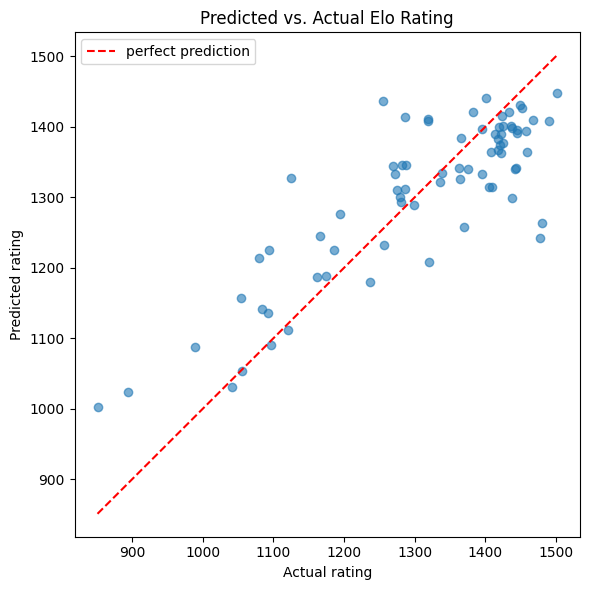

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.6)

# perfect-prediction reference line
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], "r--", label="perfect prediction")

plt.xlabel("Actual rating")
plt.ylabel("Predicted rating")
plt.title("Predicted vs. Actual Elo Rating")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
import joblib
joblib.dump(rf, "arena_rating_model.pk1")
print("Model saved to arena_rating_model.pk1")

Model saved to arena_rating_model.pk1


In [32]:
model_df.to_csv("latest_text_leaderboard.csv", index=False)
print("Dataset saved.")

Dataset saved.


In [33]:
# Project summary
# Goal was to predcit a model's Chatbot Arena Elo Rating from its metadata
# Data= Latest "text/overall" leaderboard snapshot, with one row per model
# Approach= compared linear Regression baseline against Random Forest, using vote_count, variance, organization, and license as features Excluded rank/ rating bounds to aviod any target leakage
# Results= Random Forest R^2 =.71, RMSE approx= 81 Elo points
# Most predicitve features= rating variance, organization, and vote count
# Takeaways= A models rating stability (variance) and popularity (Votes) are meaningful predicoters of its quality score, but ~29% of the variation remains unexplained, so reputation isnt fully reducible to these metadata.